In [1]:
from pathlib import Path
import copernicusmarine as cm
import xarray as xr


/opt/homebrew/Caskroom/miniconda/base/envs/emc_cc_2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
OUT_DIR = Path("/users/matzuc/Downloads/cmems") # directory di destinazione per i file scaricati
OUT_DIR.mkdir(exist_ok=True, parents=True) # creo la directory se non esiste già



In [ ]:
cm.subset(
  dataset_id="cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021",
  variables=["analysed_sst"],
  minimum_longitude=11.921724,
  maximum_longitude=18.371684,
  minimum_latitude=41.108136,
  maximum_latitude=46.103026,
  start_datetime="1982-11-01T00:00:00",
  end_datetime="2026-08-15T00:00:00",
  output_directory=OUT_DIR
) # scarico il sottoinsieme dei dati SST dal dataset CMEMS specificato


INFO - 2026-09-14T10:19:07Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO - 2026-09-14T10:19:41Z - Selected dataset version: "202411"
INFO - 2026-09-14T10:19:41Z - Selected dataset part: "default"
WARNING - 2026-09-14T10:19:44Z - Some of your subset selection [41.108136, 46.103026] for the latitude dimension exceed the dataset coordinates [30.125, 46.025001525878906]
INFO - 2026-09-14T10:19:44Z - Starting download. Please wait...
100%|██████████| 1241/1241 [00:19<00:00, 63.13it/s] 
INFO - 2026-09-14T10:20:04Z - Successfully downloaded to /users/matzuc/Downloads/cmems/cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021_analysed_sst_11.95E-18.36E_41.11N-46.03N_1982-11-01-2026-08-15.nc


ResponseSubset(file_path=PosixPath('/users/matzuc/Downloads/cmems/cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021_analysed_sst_11.95E-18.36E_41.11N-46.03N_1982-11-01-2026-08-15.nc'), output_directory=PosixPath('/users/matzuc/Downloads/cmems'), filename='cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021_analysed_sst_11.95E-18.36E_41.11N-46.03N_1982-11-01-2026-08-15.nc', file_size=389.82096564885495, data_transfer_size=2306.1808854961832, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=11.952619552612305, maximum=18.358501434326172, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=41.10954284667969, maximum=46.025001525878906, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='1982-11-01T00:00:00+00:00', maximum='2026-08-15T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [ ]:
# definisco il percorso del file SST scaricato dal dataset CMEMS
file = OUT_DIR / "cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021_analysed_sst_11.95E-18.36E_41.11N-46.03N_1982-11-01-2026-08-15.nc"

In [ ]:
ds = xr.open_dataset(file) # apro il dataset SST scaricato dal file NetCDF
ds # visualizzo il contenuto del dataset SST aperto

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 15994, latitude: 99, longitude: 129)
Coordinates:
  * time          (time) datetime64[ns] 128kB 1982-11-01 ... 2026-08-15
  * latitude      (latitude) float32 396B 41.11 41.16 41.21 ... 45.97 46.03
  * longitude     (longitude) float32 516B 11.95 12.0 12.05 ... 18.31 18.36
Data variables:
    analysed_sst  (time, latitude, longitude) float64 2GB ...
Attributes:
    history:                   GOS-CMEMS processor V4: new version
    source:                    [1982-present] ESA CCI SST v.3.0 L3C product (...
    title:                     Mediterranean Sea SST Analysis L4, Reprocessed...
    comment:                   WARNING: some applications are unable to prope...
    Conventions:               CF-1.4 
    references:                A. Pisano, B. Buongiorno Nardelli, C. Tronconi...
    institution:               GOS (Global Ocean Satellite monitoring and mar...
    copernicusmarine_version:  2.0.1

In [ ]:
sst = ds  - 273.16 # converto la temperatura superficiale del mare da Kelvin a gradi Celsius

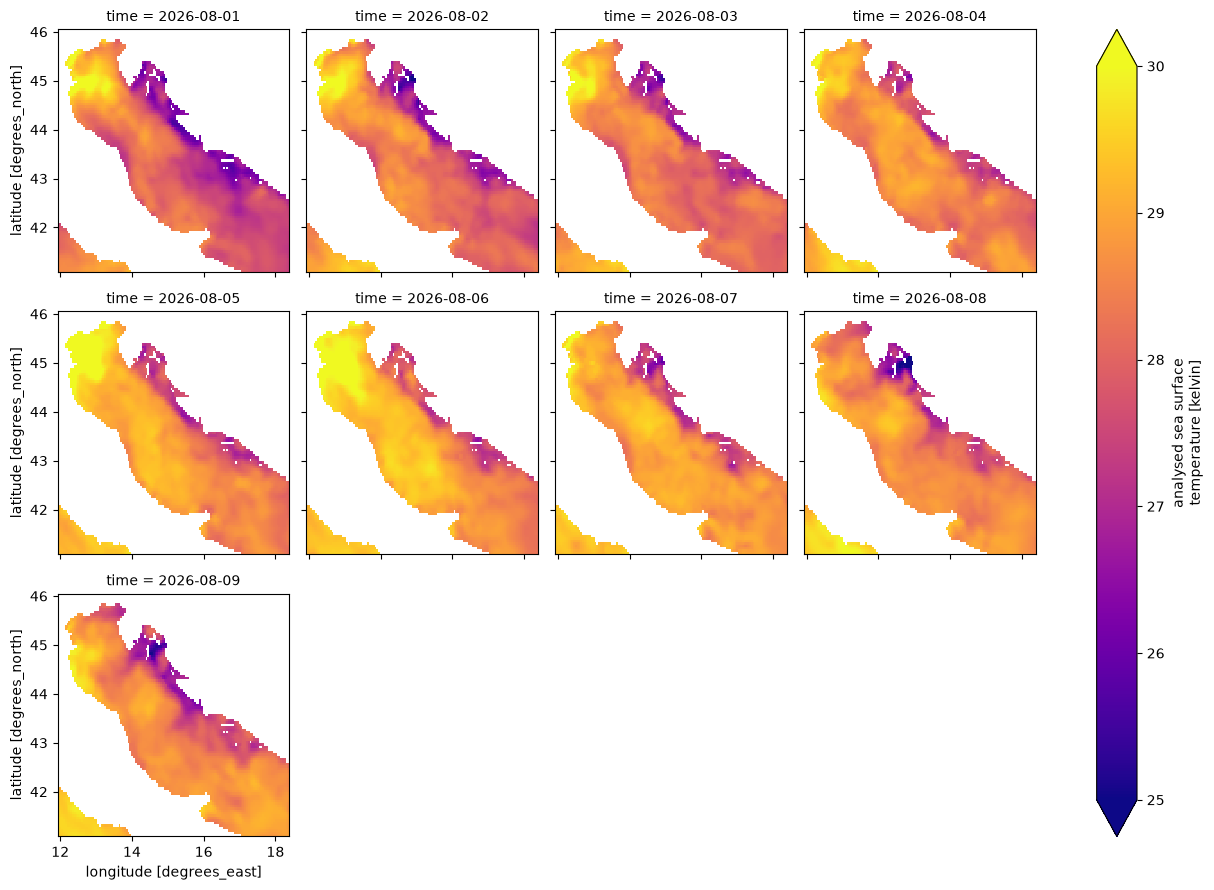

In [25]:
sst.analysed_sst.sel(time=slice("2026-08-01", "2026-08-09")).plot(
    col="time",
    col_wrap=4,
    
    vmin=25,
    vmax=30,
    cmap="plasma"
)

In [ ]:
anno = sst.time.dt.year # estraggo l'anno dalla dimensione temporale del dataset SST


<xarray.DataArray 'year' (time: 15994)> Size: 128kB
array([1982, 1982, 1982, ..., 2026, 2026, 2026], shape=(15994,))
Coordinates:
  * time     (time) datetime64[ns] 128kB 1982-11-01 1982-11-02 ... 2026-08-15
Attributes:
    long_name:      Time
    axis:           T
    unit_long:      Seconds Since 1981-01-01
    standard_name:  time

In [ ]:
media_annuale = sst.groupby(anno).mean(dim='time') # calcolo la media annuale della temperatura superficiale del mare
media_annuale

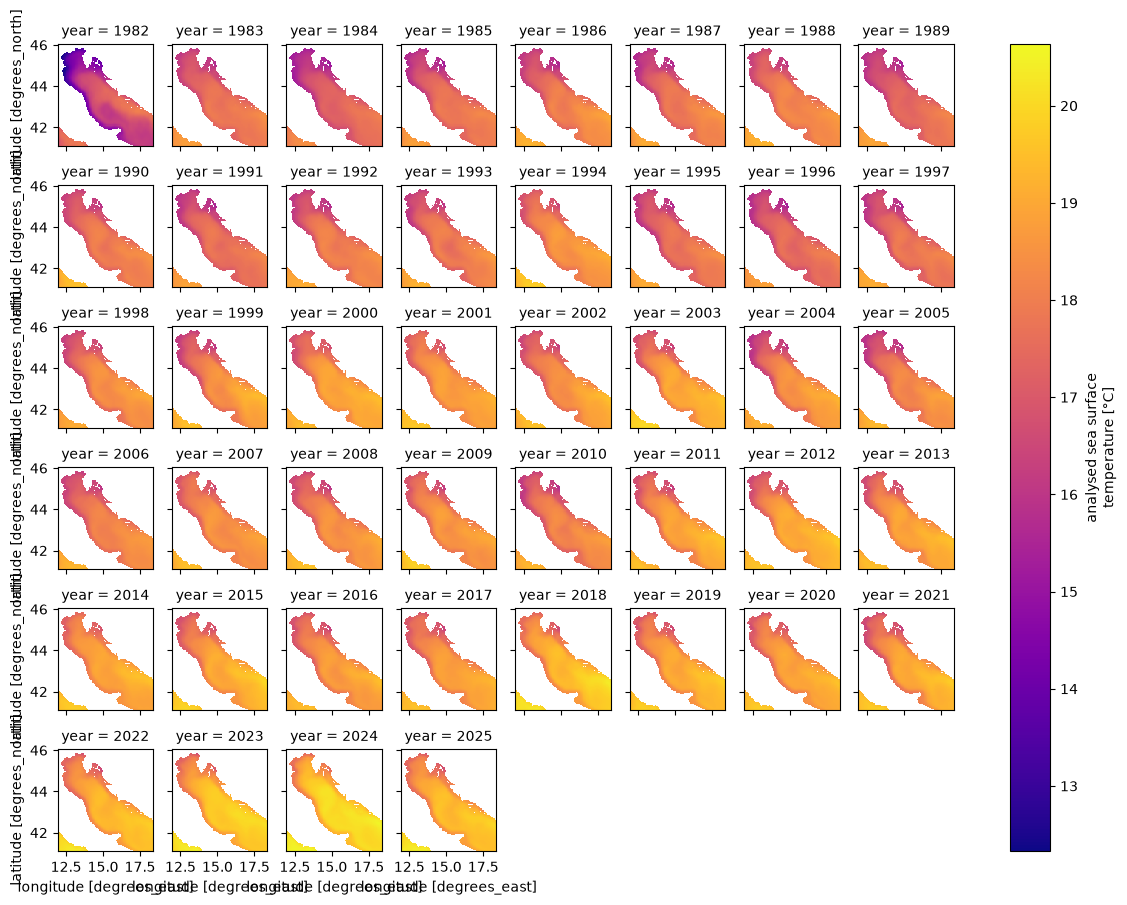

In [ ]:
daC = (media_annuale["analysed_sst"]).assign_attrs(units="°C")  # assegno l'unità di misura gradi Celsius al dataset SST annuale


daC.isel(year=slice(0, 44)).plot(col="year", col_wrap=8, 
         figsize=(12, 9),
         cmap = "plasma")

In [ ]:
daC.to_netcdf(OUT_DIR / "sst_1982_2025.nc")  # salvo il dataset SST annuale in un file NetCDF

# Medie mensili

In [ ]:
agosto = sst.analysed_sst.sel(
    time=sst.time.dt.month == 8
) # seleziono solo i dati SST relativi al mese di agosto

media_agosto = agosto.groupby("time.year").mean("time")  # calcolo la media della temperatura superficiale del mare per il mese di agosto di ogni anno  

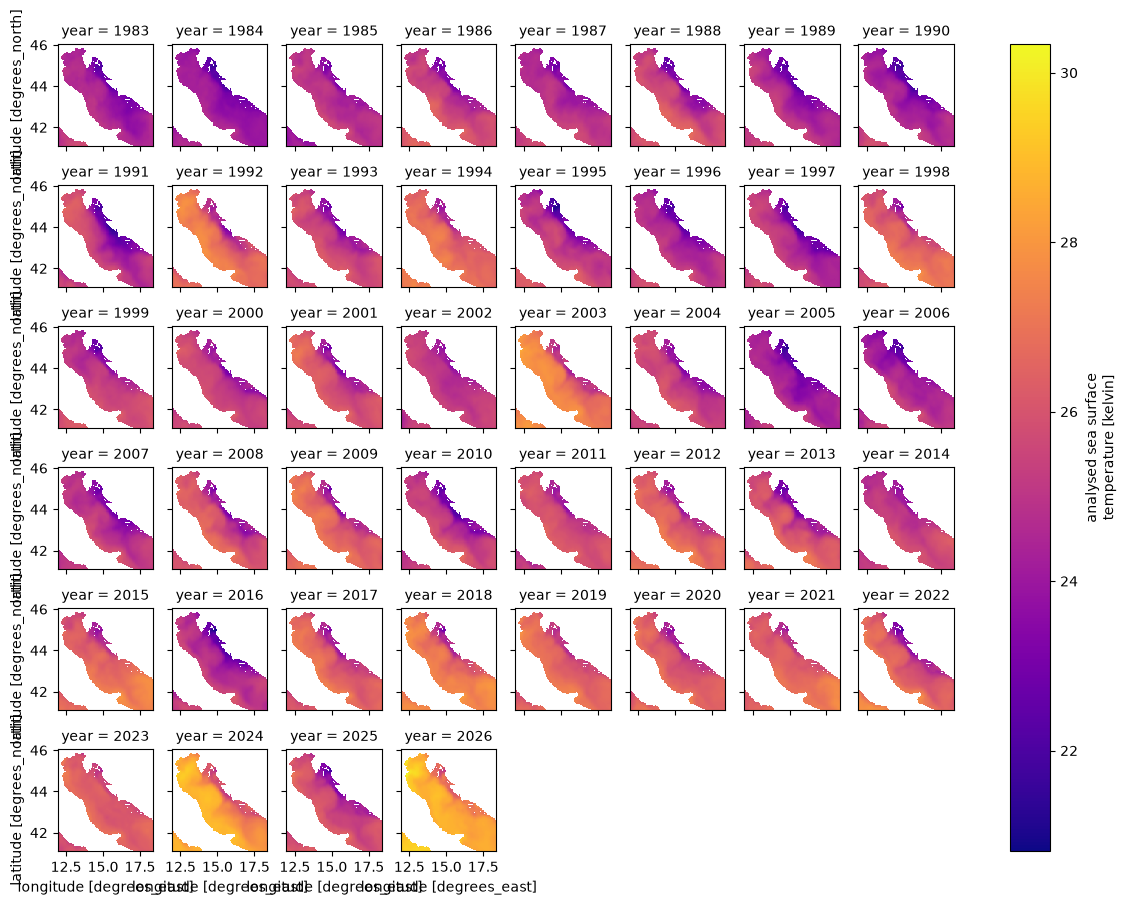

In [ ]:
media_agosto.plot(
    col="year",
    col_wrap=8,
    figsize=(12, 9),
    cmap="plasma"
)   # visualizzo la media della temperatura superficiale del mare per il mese di agosto di ogni anno

# trend lineare

In [ ]:
trend_agosto = media_agosto.polyfit(
    dim="year",
    deg=1
)  # calcolo il trend lineare della temperatura superficiale del mare per il mese di agosto di ogni anno

In [ ]:
slope = trend_agosto["polyfit_coefficients"].sel(degree=1)  # estraggo il coefficiente angolare della retta di trend lineare per il mese di agosto

In [ ]:
slopeDEC = slope * 10  # converto il trend lineare della temperatura superficiale del mare per il mese di agosto da °C/anno a °C/decade

slopeDEC.attrs["units"] = "°C/decade"   # assegno l'unità di misura del trend lineare della temperatura superficiale del mare per il mese di agosto in °C/decade
slopeDEC.attrs["long_name"] = "Trend della temperatura media di agosto"  # assegno un nome descrittivo al trend lineare della temperatura superficiale del mare per il mese di agosto


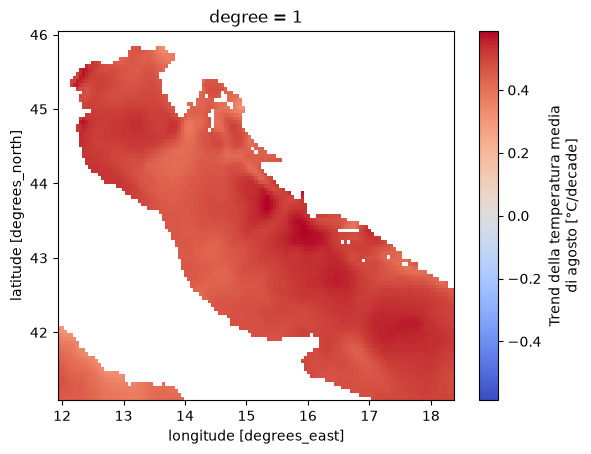

In [ ]:
slopeDEC.plot(
    cmap="coolwarm",
    center=0
)  # visualizzo il trend lineare della temperatura superficiale del mare per il mese di agosto in °C/decade

# trend media giornaliera

In [ ]:
da = sst.analysed_sst 

anni = (
    da.time.dt.year
    + (da.time.dt.dayofyear - 1) / 365.25
)  # converto le coordinate temporali in anni decimali

da_anni = da.assign_coords(time=anni)  # assegno le coordinate temporali in anni decimali al dataset

trend = da_anni.polyfit(
    dim="time",
    deg=1
)  # calcolo il trend lineare della temperatura superficiale del mare in anni decimali

slope = trend.polyfit_coefficients.sel(degree=1)  # estraggo il coefficiente angolare della retta di trend lineare

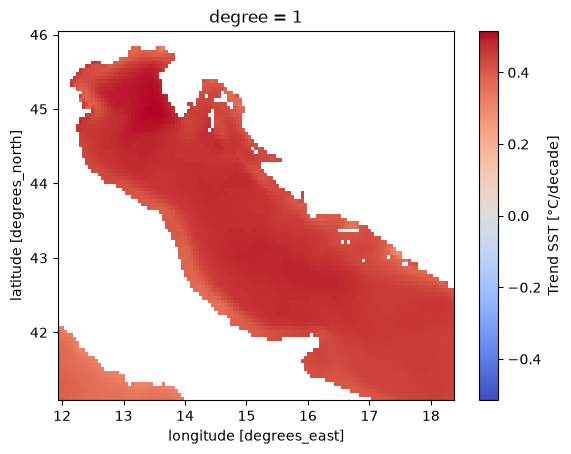

In [ ]:
trend_decade = slope * 10  # converto il trend lineare della temperatura superficiale del mare da °C/anno a °C/decade

trend_decade.attrs["units"] = "°C/decade"  # assegno l'unità di misura del trend lineare della temperatura superficiale del mare in °C/decade
trend_decade.attrs["long_name"] = "Trend SST"  # assegno un nome descrittivo al trend lineare della temperatura superficiale del mare

trend_decade.plot(
    cmap="coolwarm",
    center=0
)  # visualizzo il trend lineare della temperatura superficiale del mare in °C/decade